<a href="https://colab.research.google.com/github/WuDianQiBian/WuDianQiBian/blob/main/notebooks/ch02_python_basics/sec04_numpy_1_answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NumPy 1 思考题

<p align="center">
  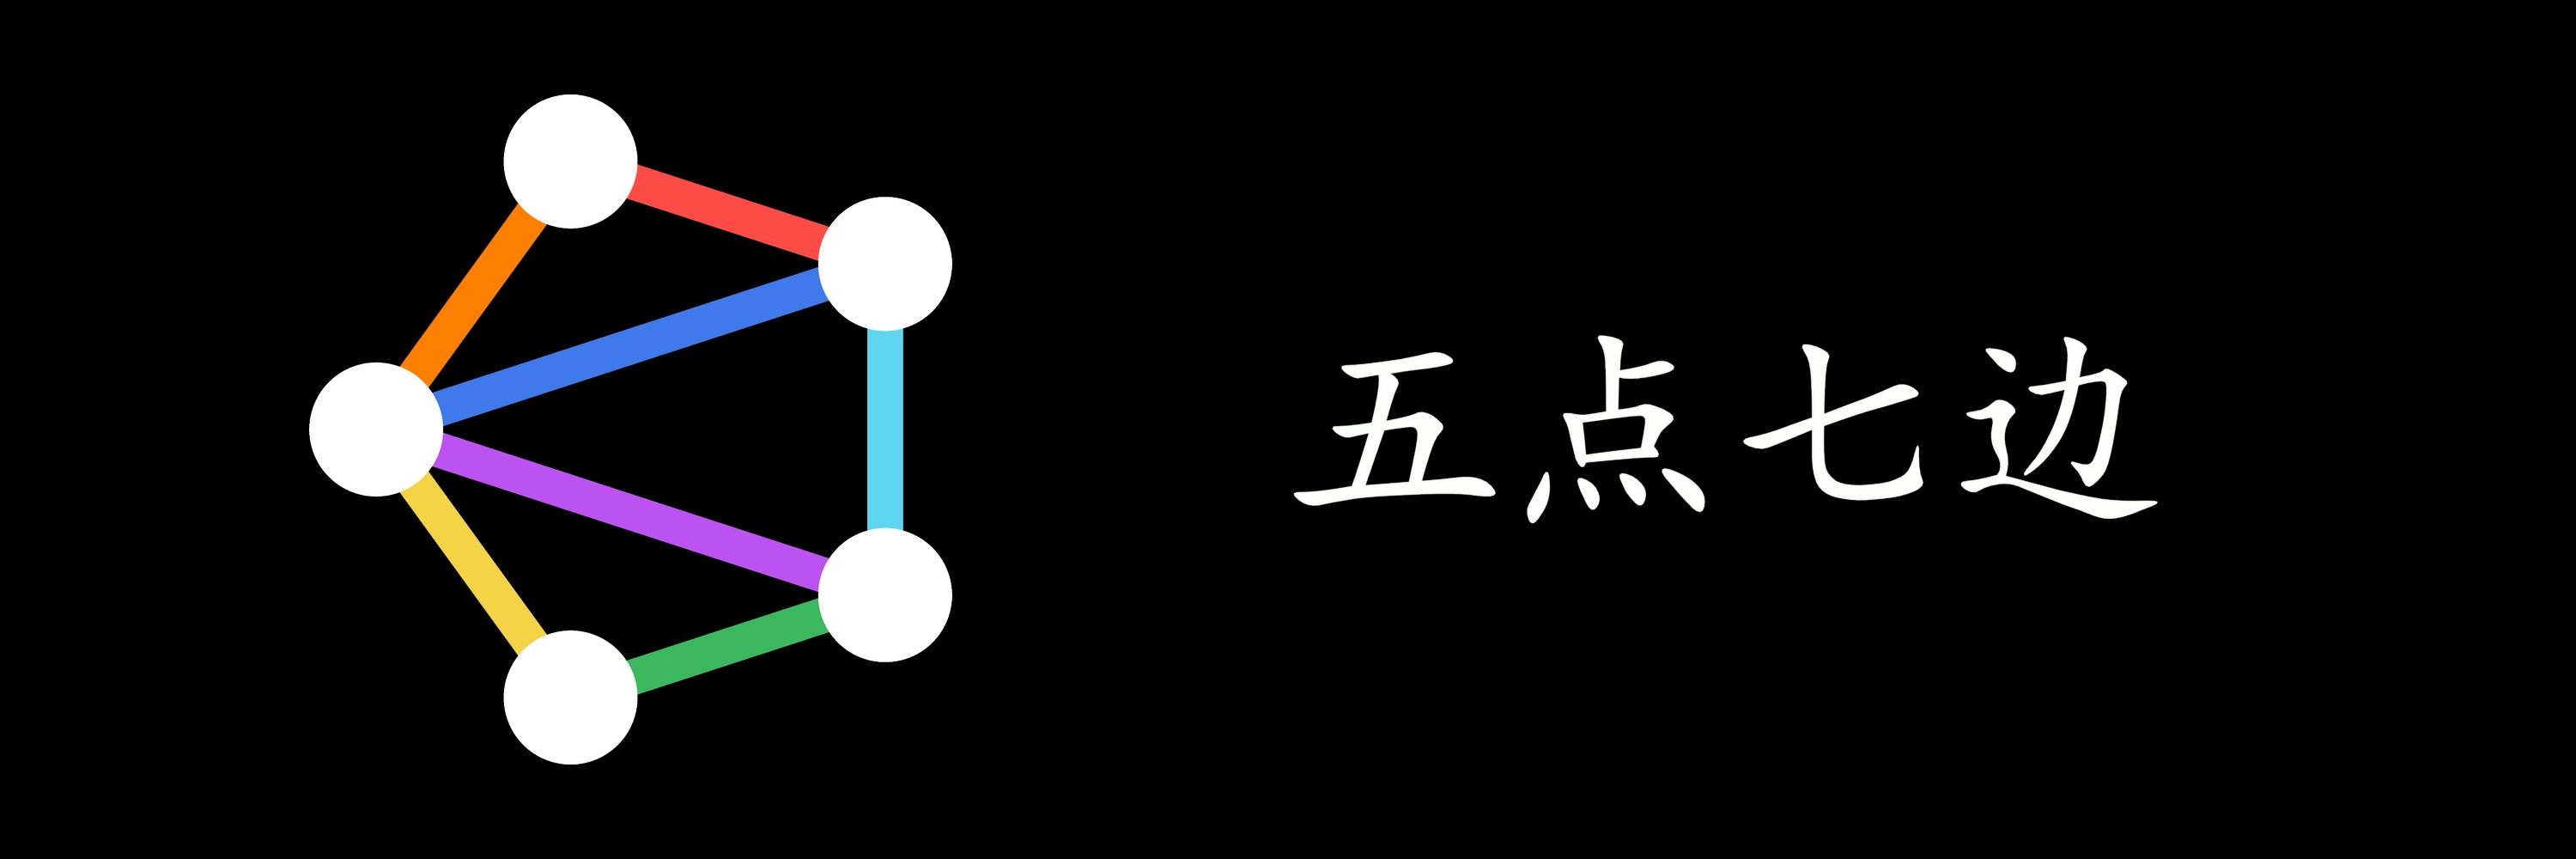
</p>


如何用broadcasting给图片加入径向渐变效果?
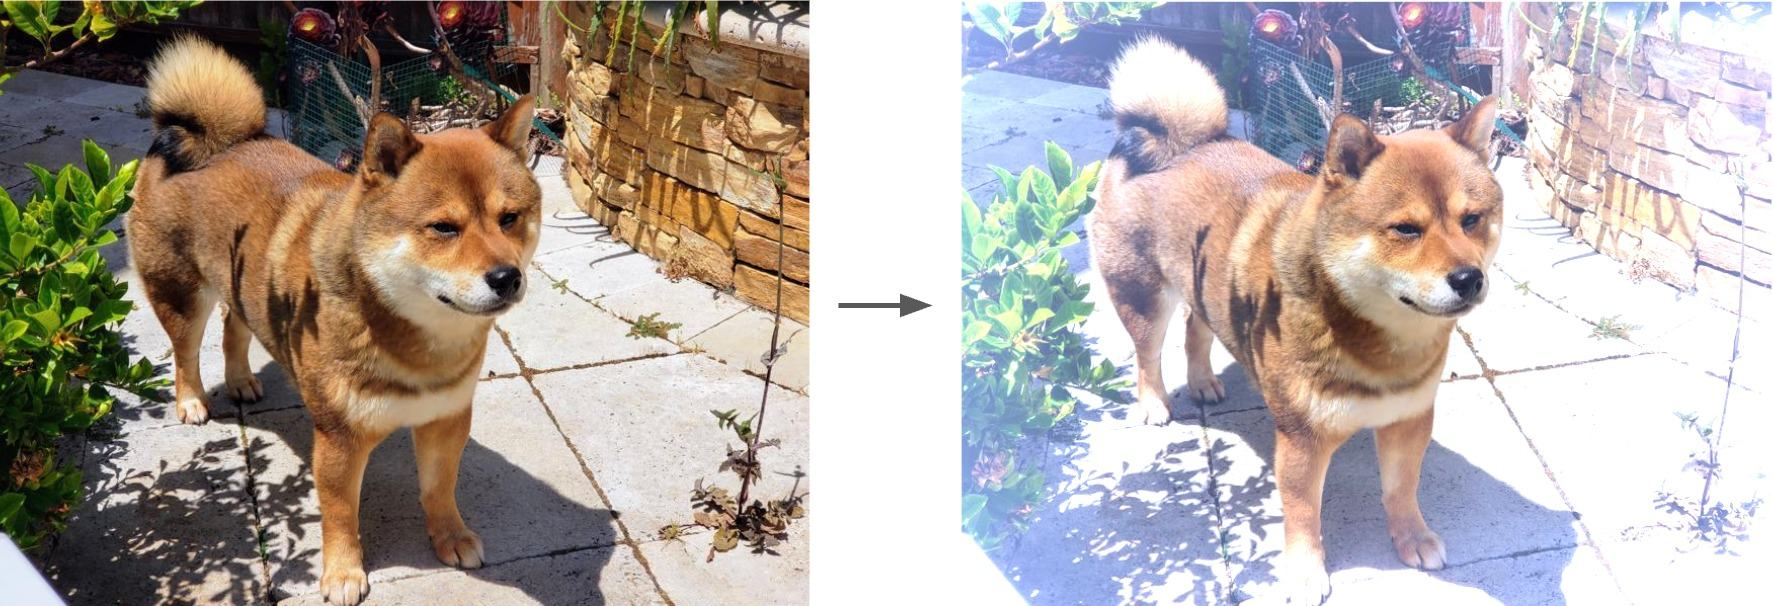

**提示:**
1. 仅用本节课中学到的内容
2. 尝试先生成一张“径向渐变”的mask

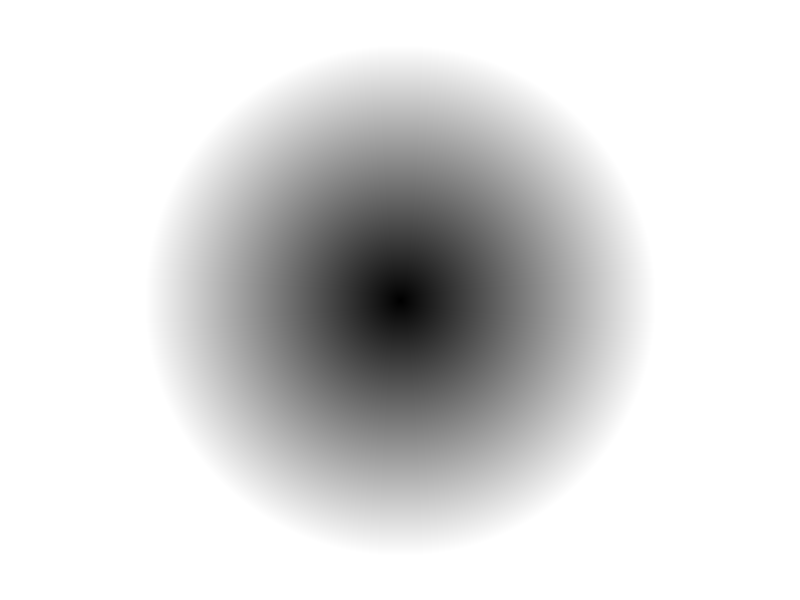


# 答案

In [1]:
# @title 辅助函数
import numpy as np
from PIL import Image
from IPython.display import display

np.set_printoptions(threshold=10, edgeitems=5)

!wget -q -nc --directory-prefix=downloads https://raw.githubusercontent.com/WuDianQiBian/ml-course/master/notebooks/ch02_python_basics/assets/Clark.jpg

def read_image(path="downloads/Clark.jpg"):
    return np.asarray(Image.open(path)).copy()

def display_image(img):
    display(Image.fromarray(img))

H=600, W=800


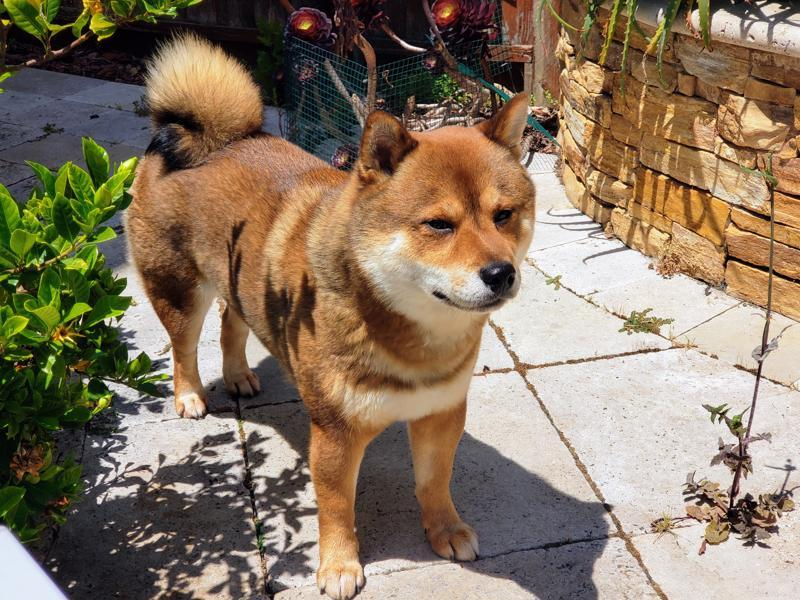

In [2]:
# 读取图片，获取高度和宽度
image = read_image()
H, W, _ = image.shape

print(f"{H=}, {W=}")
display_image(image)

In [3]:
# 生成横坐标和纵坐标
x = np.arange(W).reshape(1, W)  # (1, W)
y = np.arange(H).reshape(H, 1)  # (H, 1)

print("x:\n", x)
print("y:\n", y)

x:
 [[  0   1   2   3   4 ... 795 796 797 798 799]]
y:
 [[  0]
 [  1]
 [  2]
 [  3]
 [  4]
 ...
 [595]
 [596]
 [597]
 [598]
 [599]]


In [4]:
x_to_center = x - W // 2      # (1, W)
y_to_center = y - H // 2      # (H, 1)

print("x_to_center:\n", x_to_center)
print("y_to_center:\n", y_to_center)

x_to_center:
 [[-400 -399 -398 -397 -396 ...  395  396  397  398  399]]
y_to_center:
 [[-300]
 [-299]
 [-298]
 [-297]
 [-296]
 ...
 [ 295]
 [ 296]
 [ 297]
 [ 298]
 [ 299]]


In [5]:
# 计算每个像素到图像中心的距离（关键!)
dist = np.sqrt(x_to_center ** 2 + y_to_center ** 2)       # (1, W) + (H, 1) -> (H, W)
# 注释: **2是平方运算

print(f"{dist.shape=}")

dist.shape=(600, 800)


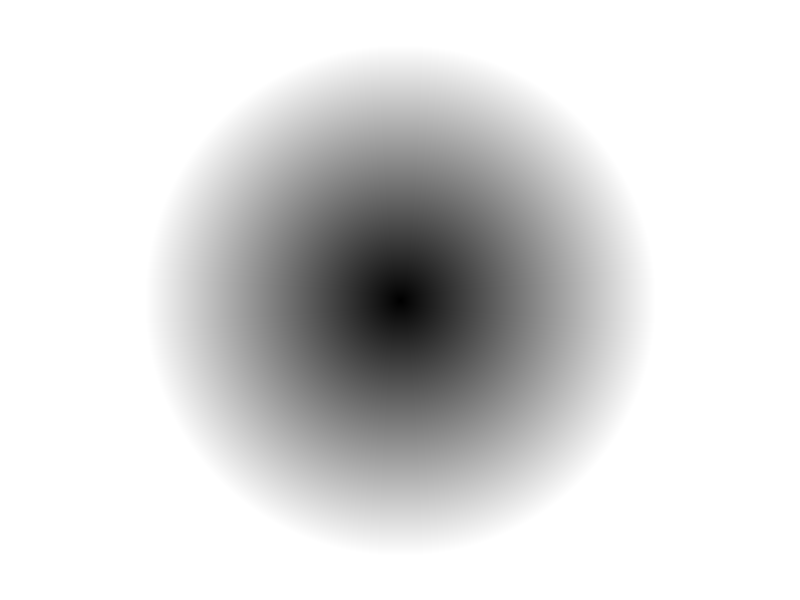

In [6]:
# 查看距离场：中心最暗，越往外越亮
dist_image = dist.clip(0, 255).astype(np.uint8)
display_image(dist_image)

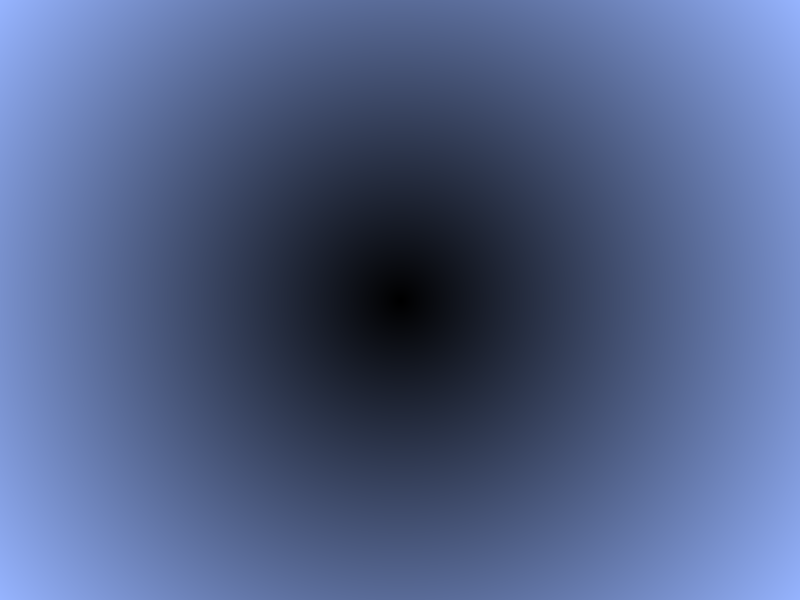

In [7]:
# 将距离normalize到[0, 1), 作为权重
dist_norm = dist / (dist.max() + 1e-12)               # (H, W)

# 生成光晕层:
glow_color = np.array([150, 180, 255])                # 月光色, shape: (3,)
glow_color = glow_color.reshape(1, 1, 3)              # (3,) -> (1, 1, 3)
glow_layer = glow_color * dist_norm.reshape(H, W, 1)  # (1, 1, 3) + (H, W, 1) -> (H, W, 3)

# 检查光晕层:
display_image(glow_layer.clip(0, 255).astype(np.uint8))

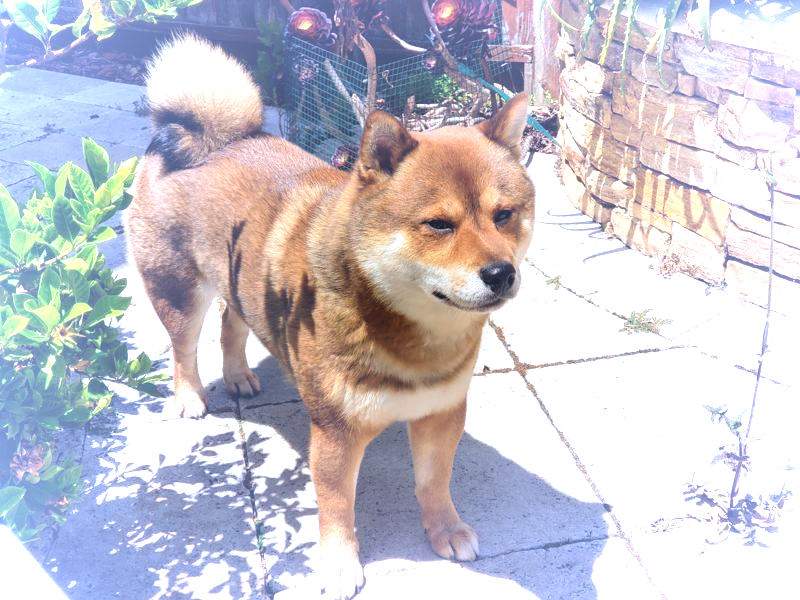

In [8]:
# 叠加到原始图片
result = (image + glow_layer).clip(0, 255).astype(np.uint8)
display_image(result)